In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Caminhos relativos 
train_path = "../data/train.csv" 
test_path = "../data/test.csv"

# Carregar datasets 
df_train = pd.read_csv(train_path) 
df_test = pd.read_csv(test_path)

### **Sobre o projeto**

Esse projeto usa uma base de dados com as informações dos passageiros que estavam no Titanic. O objetivo do modelo a ser desenvolvido é prever quais pessoas sobreviveram ou não ao desastre, e se existe alguma relação entre a taxa de sobrevivência e um grupo específico.

A base de dados já vem com a etapa train_test_split concluída. As variáveis são:

- **PassengerId** - Id do passageiro
- **Survived** - sobrevivência (0 = não, 1 = sim)
- **Pclass** - classe do ticket (1, 2 e 3)
- **Name** - nome 
- **Sex** - sexo (male, female)
- **Age** - idade em anos
- **SibSp** - número de familiares, considerando irmãos e marido/esposa
- **Parch** - número de familiares, considerando pais e crianças
- **Ticket** - número do ticket
- **Fare** - tarifa 
- **Cabin** - número da cabine
- **Embarked** - porto (C = Cherbourg, Q = Queenstown, S = Southampton)

(A base de teste não inclui os registros "Survived")

In [54]:
# Colunas dos dataFrames
df_train.columns
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

---

#### **Data Inspection**

Dados de Treino: 
- 891 registros
- Valores nulos em Age (177), Cabin (687), Embarked (2)

Dados de Teste: 
- 418 Registros
- Valores nulos em Age (86), Cabin (327), Fare(1)

Dados no formato string: Name, Sex, Ticket, Cabin, Embarked

In [55]:
# Número de registros e colunas
df_train.shape, df_test.shape

((891, 12), (418, 11))

In [56]:
# Tipos de dados e identificação de valores nulos
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [57]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [58]:
# Informações gerais da base de treino
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [59]:
# Informações gerais da base de teste
df_test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


---

#### **Data Cleaning + Feature Engineering**

Cerca de 77.5% dos registros de **Cabin** são nulos (77.1% em df_train e 78.2% em df_test). Por isso, essa coluna será desconsiderada da base de dados para realização dos treinamentos e previsões.

In [60]:
# Retirar coluna Cabin
df_train = df_train.drop('Cabin', axis=1)
df_test = df_test.drop('Cabin', axis=1)

Na base de dados de teste, existe 1 registro com valor Null em **Fare**. Será adicionado o valor da mediana da sua classe, levando em conta que a distribuição das taxas possui assimetria positiva.

In [61]:
# Calcular mediana da tarifa na mesma classe que a do registro
median_p3 = df_test[df_test['Pclass'] == 3]['Fare'].median()

# Adicionar a mediana no registro
df_test.loc[df_test['Fare'].isnull(), 'Fare'] = median_p3

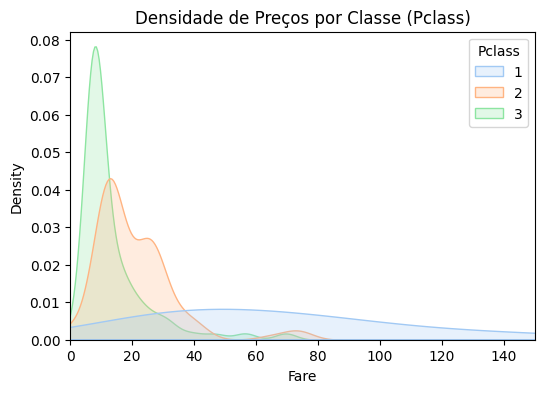

In [62]:
# Relaciona a taxa com a classe do ticket

plt.figure(figsize=(6, 4))

# Comparando a densidade de preços por classe
sns.kdeplot(data=df_train, x='Fare', hue='Pclass', fill=True, palette='pastel', common_norm=False)

# Limitando o X em 150 para conseguir enxergar as curvas, 
# senão o gráfico fica muito "esticado" por causa dos valores caros.
plt.xlim(0, 150) 

plt.title('Densidade de Preços por Classe (Pclass)')
plt.show()

Dois registros da base de dados de treino estão com o valor **Embarked** nulo. Ambos têm pclass = 1 e Fare = 80.
De acordo com os dados, pode-se assumir que o porto principal de embarque foi o de Southampton (S). Além disso:

- Classe 1: maioria em (S) e (C);
- Classe 2: principalmente em (S);
- Classe 3: principalmente em (S), os que mais embarcaram em (Q).

Dada a paridade na proporção de sobrevivência entre os portos S e C para passageiros de 1ª Classe, utilizou-se a variável Fare como critério de desempate. Considerando o valor da média e da mediana dos portos, foi selecionado o porto C para preenchimento dos valores nulos. 

In [63]:

mean = df_train[df_train['Pclass'] == 1].groupby('Embarked')['Fare'].mean()
median = df_train[df_train['Pclass'] == 1].groupby('Embarked')['Fare'].median()

print(f"Median: {median}\n ------------ \nMean: {mean}\n")

Median: Embarked
C    78.2667
Q    90.0000
S    52.0000
Name: Fare, dtype: float64
 ------------ 
Mean: Embarked
C    104.718529
Q     90.000000
S     70.364862
Name: Fare, dtype: float64



In [64]:
# Adicionar o porto nos registros
df_train.loc[df_train['Embarked'].isnull(), 'Embarked'] = "C"

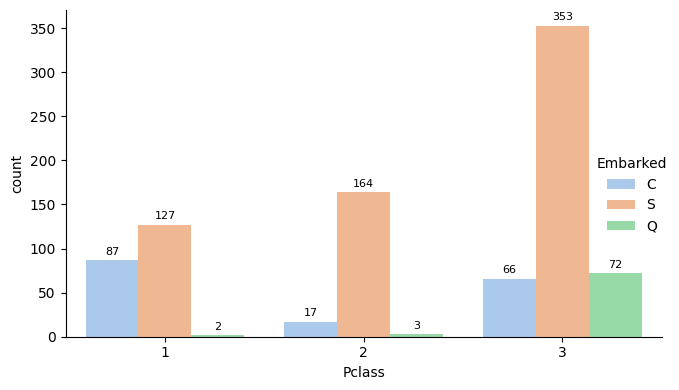

In [65]:
# Mostra a relação entre os portos e as classes do ticket - Embarked
g = sns.catplot(data=df_train, x='Pclass', hue='Embarked', kind='count', palette='pastel', legend=True, height=4, aspect=1.5)

for ax in g.axes.flat:

    # Coloca os números em cima das barras
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 6), 
                        textcoords='offset points',
                        fontsize=8)

plt.tight_layout()
plt.show()

Os **títulos sociais** serão obtidos a partir da variável "Name", já que podem indicar classe/status no período do acidente, e consequentemente, podem estar relacionados de alguma forma com a taxa de sobrevivência desses passageiros. Alguns títulos sociais mais dispersos serão agrupados em Rare.

In [66]:
import re 

# Extrair título do nome 
df_train['Title'] = df_train['Name'].apply(lambda x: re.search(r',\s*([^\.]*)\.', x).group(1).strip())
df_test['Title'] = df_test['Name'].apply(lambda x: re.search(r',\s*([^\.]*)\.', x).group(1).strip())

# Dicionário para realizar agrupamento
title_mapping = { 
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master', 
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Mlle': 'Miss',  
    'Ms': 'Miss',    
    'Mme': 'Mrs',    
    'Don': 'Rare',
    'Dona': 'Rare',
    'Lady': 'Rare',
    'Countess': 'Rare',
    'Jonkheer': 'Rare',
    'Sir': 'Rare',
    'Capt': 'Rare'
}

# Agrupar
df_train['TitleGroup'] = df_train['Title'].map(title_mapping)
df_test['TitleGroup'] = df_test['Title'].map(title_mapping)

# Caso algum título novo não esteja no dicionário, é considerado 'Rare'
df_train['TitleGroup'] = df_train['TitleGroup'].fillna('Rare')
df_test['TitleGroup'] = df_test['TitleGroup'].fillna('Rare')

print(df_train['TitleGroup'].value_counts())
print(df_test['TitleGroup'].value_counts())


TitleGroup
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64
TitleGroup
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64


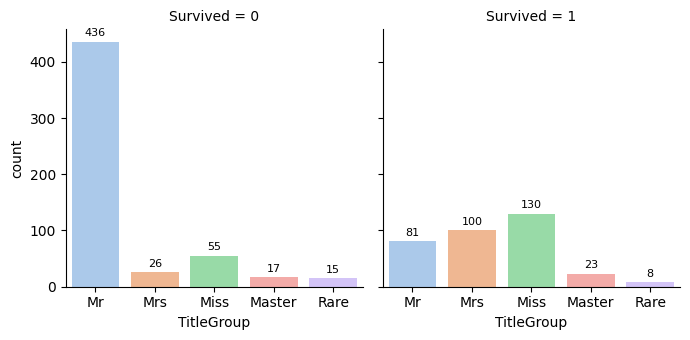

In [67]:
# Compara a sobrevivência com base no título - TitleGroup
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(data=df_train, x='TitleGroup', hue='TitleGroup', col='Survived', kind='count', palette='pastel', legend=False, height=3.5)

for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontsize=10)
    
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 6), 
                        textcoords='offset points',
                        fontsize=8) 

plt.tight_layout()
plt.show()

Alguns registros não possuem a idade. Neste caso, o valor Age dos registros foi preenchido com a mediana de seu respectivo TitleGroup.

In [68]:
df_train['Age'] = df_train['Age'].fillna(df_train.groupby('TitleGroup')['Age'].transform('median'))
df_test['Age'] = df_test['Age'].fillna(df_test.groupby('TitleGroup')['Age'].transform('median'))

As features SibSp e Parch foram unidas em um grupo "Family", já que juntas representam o **núcleo familiar** do passageiro (incluso no grupo).

In [69]:
# Somando os valores das colunas e armazendo em Family
df_train['Family'] = df_train['SibSp'] + df_train['Parch'] + 1
df_test['Family'] = df_test['SibSp'] + df_test['Parch'] + 1

As **idades** foram remodeladas em 8 grupos, cada um representando uma década de vida (exemplo: grupo 1 - pessoas com até  10 anos, grupo 2 - pessoas com até 20 anos, etc). 

In [70]:
# Agrupando as idades 
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]   # limites dos grupos 
labels = [1, 2, 3, 4, 5, 6, 7, 8]            # nomes dos grupos

df_train['AgeGroup'] = pd.cut(df_train['Age'], bins=bins, labels=labels, right=True)
df_test['AgeGroup'] = pd.cut(df_test['Age'], bins=bins, labels=labels, right=True)

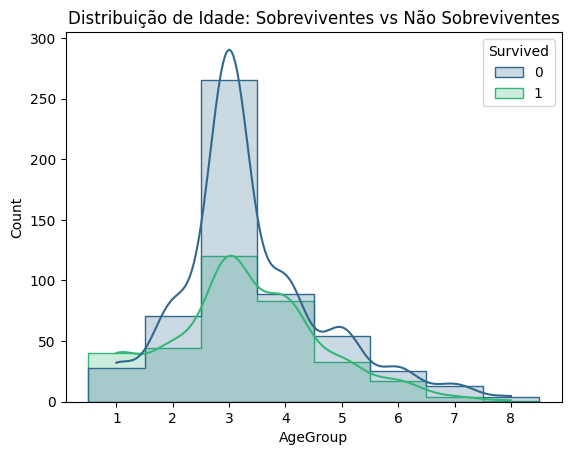

In [71]:
# Compara a sobrevivência com base na idade - AgeGroup
sns.histplot(data=df_train, x='AgeGroup', hue='Survived', kde=True, element="step", palette='viridis')

plt.title('Distribuição de Idade: Sobreviventes vs Não Sobreviventes')
plt.show()

---

#### **Pre-Processing**

Para utilizar o LabelEncoder e o OneHotEncoder, iremos criar as bases de dados x_train, x_test e y_train somente com as colunas que serão utilizadas no treinamento e que já foram ajustadas.

In [72]:
features = ['Pclass', 'Sex', 'Fare', 'Embarked', 'TitleGroup', 'Family', 'AgeGroup']
x_train = df_train[features]
y_train = df_train['Survived']

x_test = df_test[features]

Aplicação do LabelEncoder na variável "Sex": 

In [73]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

x_train['Sex'] = le.fit_transform(x_train['Sex'])
x_test['Sex'] = le.transform(x_test['Sex'])

Aplicação do OneHotEncoder nas variáveis "Embarked" e "TitleGroup" (não ordinais):

In [74]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# drop first serve para que o modelo entenda os valores por exclusão
ohe = ColumnTransformer(transformers=[('Onehot', OneHotEncoder(drop='first', sparse_output=False), ['Embarked', 'TitleGroup'])], 
                                          remainder='passthrough')


x_train_array = ohe.fit_transform(x_train)
x_test_array = ohe.transform(x_test)

new_columns = ohe.get_feature_names_out()

x_train = pd.DataFrame(x_train_array, columns=new_columns, index=x_train.index)
x_test = pd.DataFrame(x_test_array, columns=new_columns, index=x_test.index)

Agora todas as colunas são interpretáveis (float64), não há valores nulos, e estão sendo consideradas as variáveis relevantes para o treinamento e previsão do modelo.

In [ ]:
x_train.info()
x_test.info()

Salvando os dados:

In [90]:
x_train.to_csv('../data/x_train.csv', index=False)
x_test.to_csv('../data/x_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)

---

#### **Extraindo informações**

Comportamento da taxa de sobrevivência:
- Mais alta para mulheres e crianças;
- Mais alta para os Tickets de classe 1 e 2;
- Mais alta para famílias de 2 a 4 pessoas.

In [75]:
df_train.groupby(['SibSp'], as_index=False)['Survived'].agg(['count','mean'])

,SibSp,count,mean
0,0,608,0.345395
1,1,209,0.535885
2,2,28,0.464286
3,3,16,0.250000
4,4,18,0.166667
5,5,5,0.000000
6,8,7,0.000000


In [76]:
df_train.groupby(['Family'], as_index=False)['Survived'].agg(['count','mean'])

,Family,count,mean
0,1,537,0.303538
1,2,161,0.552795
2,3,102,0.578431
3,4,29,0.724138
4,5,15,0.200000
5,6,22,0.136364
6,7,12,0.333333
7,8,6,0.000000
8,11,7,0.000000


In [77]:
df_train.groupby(['Sex'], as_index=False)['Survived'].agg(['count','mean'])

,Sex,count,mean
0,female,314,0.742038
1,male,577,0.188908


In [78]:
df_train.groupby(['TitleGroup'], as_index=False)['Survived'].agg(['count','mean'])

,TitleGroup,count,mean
0,Master,40,0.575000
1,Miss,185,0.702703
2,Mr,517,0.156673
3,Mrs,126,0.793651
4,Rare,23,0.347826


In [79]:
df_train.groupby(['Pclass'], as_index=False)['Survived'].agg(['count','mean'])

,Pclass,count,mean
0,1,216,0.629630
1,2,184,0.472826
2,3,491,0.242363


In [80]:
df_train.groupby(['Parch'], as_index=False)['Survived'].agg(['count','mean'])

,Parch,count,mean
0,0,678,0.343658
1,1,118,0.550847
2,2,80,0.500000
3,3,5,0.600000
4,4,4,0.000000
5,5,5,0.200000
6,6,1,0.000000
